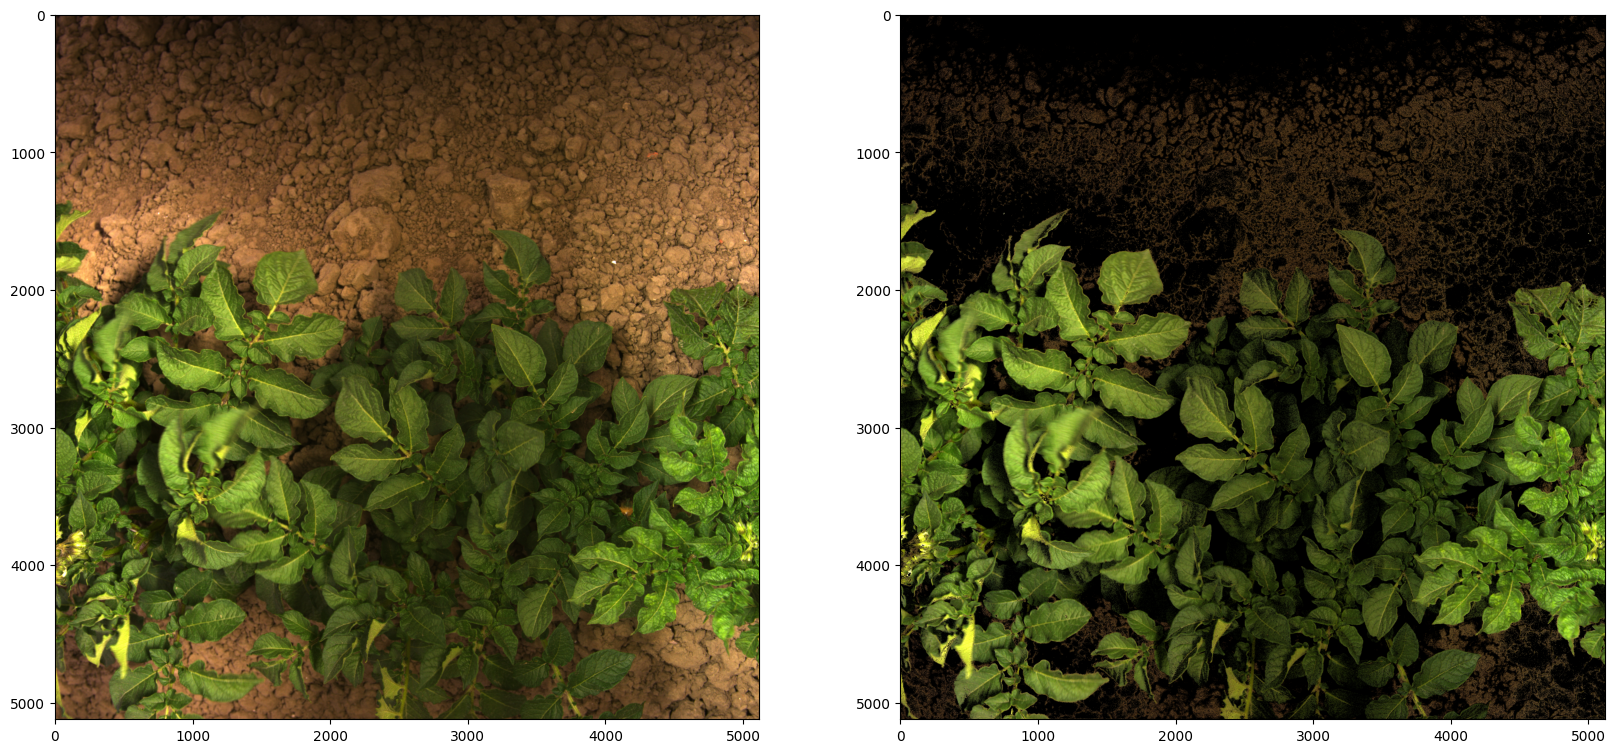

In [7]:
import skimage.io
import matplotlib.pyplot as plt
import numpy as np
import torch
from gmlvq import gmlvq
import pixel_classification_train as helper

# img = skimage.io.imread("uh-lettuce.png")
# img = skimage.io.imread("../../output/normalized_16bpc.png")
# img = skimage.io.imread("../../output/output.png")
img = skimage.io.imread("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train/2ec83b5a-f1ad-4dae-bb33-773f1eee7923.png")

lvq = gmlvq()
lvq.load('pix-classifier-2025-07-03-leaves.pt')    

feats = torch.from_numpy(helper.rgb_uint8_to_feats(img))

with torch.no_grad():
    dist = lvq.net.proto_distances(feats).detach().numpy()

scalar = dist[:, 0] - dist[:, 1]
scalar = scalar.reshape(img.shape[0:2])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20,20))
ax0.imshow(img)
img[scalar < 0.0, :] = 0
ax1.imshow(img)

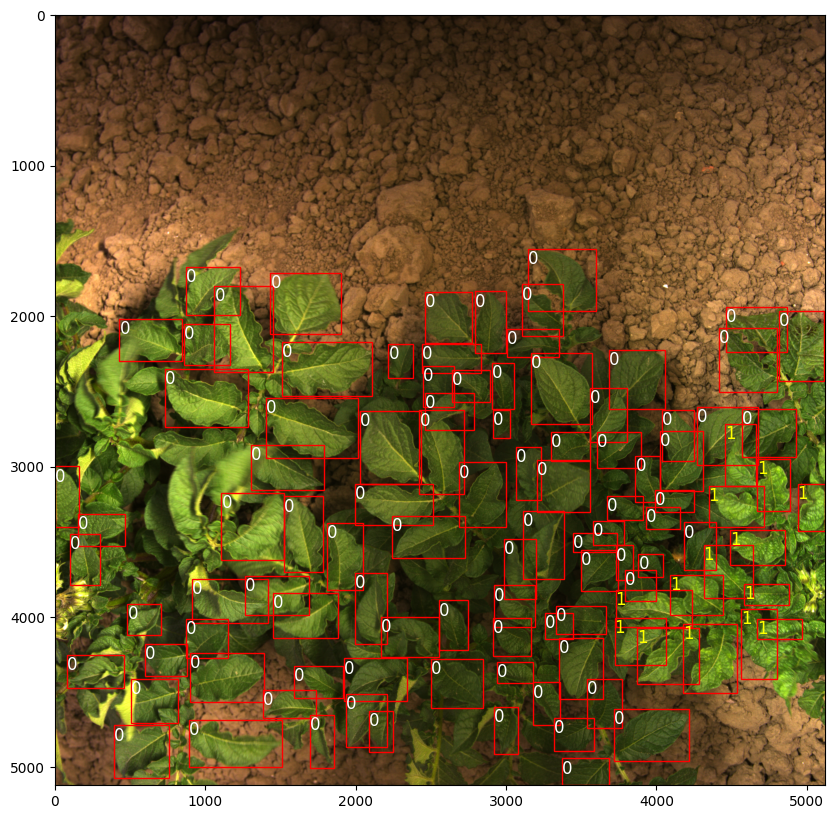

In [8]:
def parse_labels(file_path):
    parsed_data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue  # Skip malformed lines
            label = int(parts[0])
            bbox = list(map(float, parts[1:]))  # [x_center, y_center, width, height]
            parsed_data.append((label, bbox))
    return parsed_data

img = skimage.io.imread("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train/2ec83b5a-f1ad-4dae-bb33-773f1eee7923.png")
labels = parse_labels("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train/2ec83b5a-f1ad-4dae-bb33-773f1eee7923.txt")
# img = skimage.io.imread("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train/a9e37804-c00a-4e4e-b99f-e267a0056a05.png")
# labels = parse_labels("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train/a9e37804-c00a-4e4e-b99f-e267a0056a05.txt")

fig, ax1 = plt.subplots(figsize=(10,10))
div = 320 # 5120/320=16 so makes 16x16 grids
# for i in range(0, div):
#     for j in range(0, div):
#         x = i * img.shape[1] // div
#         y = j * img.shape[0] // div
#         x1 = x + img.shape[1] // div
#         y1 = y + img.shape[0] // div
#         rect = plt.Rectangle((x, y), img.shape[1] // div, img.shape[0] // div, linewidth=0.1, edgecolor='blue', facecolor='none')
#         ax1.add_patch(rect)
for label, bbox in labels:
    x_center, y_center, width, height = bbox
    x_center = int(x_center * img.shape[1])
    y_center = int(y_center * img.shape[0])
    width = int(width * img.shape[1])
    height = int(height * img.shape[0])
    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)
    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)
    
    rect = plt.Rectangle((x1, y1), width, height, linewidth=1, edgecolor='r', facecolor='none')
    ax1.add_patch(rect)
    color = 'white' if not label else 'yellow'
    ax1.text(x1, y1 + 100, str(label), color=color, fontsize=12)
ax1.imshow(img)

In [9]:
lvq2 = gmlvq()
features = (img.shape[0] // div) * (img.shape[1] // div)
print(f"Features: {features}")
# soil, healthy and unhealthy leaves
prototypes = 3
initial_prototypes = torch.randn(prototypes, features)
prototype_labels = [0, 1, 2]
mu = torch.randn(features)
std = torch.rand(features) + 0.1

# lvq2.initialize(features, initial_prototypes, prototype_labels, True, mu, std)
# print(img.shape)
from pathlib import Path
directory = Path("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train")
for file_path in directory.glob("*.txt"):
    # print(f"Processing {file_path}")
    l = parse_labels(file_path)
    # remove labels with width or height of 0
    l = [(label, bbox) for label, bbox in l if bbox[2]*img.shape[1] > 0 and bbox[3]*img.shape[0] > 0]
    labels += l

# find smallest width and height values of the bounding boxes
min_width = min(bbox[2] for _, bbox in labels)
min_height = min(bbox[3] for _, bbox in labels)
max_width = max(bbox[2] for _, bbox in labels)
max_height = max(bbox[3] for _, bbox in labels)
print(f"Min width: {int(min_width * img.shape[1])}, Min height: {int(min_height* img.shape[0])}")
print(f"Max width: {int(max_width * img.shape[1])}, Max height: {int(max_height * img.shape[0])}")

Features: 256
Min width: 74, Min height: 15
Max width: 1024, Max height: 895
